## 1. Setup

In [ ]:
!pip install -q grad-cam captum scikit-posthocs seaborn scipy shap lime scikit-image

In [ ]:
import os, gc, json, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.models import maxvit_t

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Configuration

In [ ]:
# ─── PATHS ─────────────────────────────────────────────────
DATA_DIR   = "./unified_ultasound_dataset"
MODEL_PATH = "./maxvit-model/maxvit_model.pth"
OUTPUT_DIR = "xai_outputs"
SALIENCY_DIR = os.path.join(OUTPUT_DIR, "saliencies")

# Mask root: contains subfolders 'benign' and 'malignant'
MASK_ROOT  = "./unified_ultrasound_dataset/masks"

# ─── DATA / MODEL ──────────────────────────────────────────
IMG_SIZE     = 224
NUM_CLASSES  = 3
CLASS_NAMES  = ["benign", "malignant", "normal"]
DROPOUT      = 0.3

# ─── XAI EVALUATION ────────────────────────────────────────
N_EVAL_IMAGES = 60       # stratified subset size
TOP_K_PERCENT = 15
DEL_INS_STEPS = 20
RISE_N_MASKS  = 1000
SHAP_NSAMPLES = 200      # SHAP: number of perturbation samples per image
LIME_NSAMPLES = 1000     # LIME: number of perturbation samples per image
LIME_SEGMENTS = 50       # LIME: target number of superpixels
SEED          = 42

# ─── MEMORY KNOBS ──────────────────────────────────────────
RISE_BATCH = 16
IG_BATCH   = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SALIENCY_DIR, exist_ok=True)
torch.manual_seed(SEED); np.random.seed(SEED)

## 3. Memory Helpers

In [ ]:
def free():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def mem_report(tag=""):
    if torch.cuda.is_available():
        a = torch.cuda.memory_allocated() / 1e9
        r = torch.cuda.memory_reserved()  / 1e9
        print(f"  [{tag}] GPU alloc={a:.2f}GB reserved={r:.2f}GB")

free(); mem_report("init")

  [init] GPU alloc=0.00GB reserved=0.00GB


## 4. Load Trained MaxViT

In [ ]:
def build_maxvit(num_classes=NUM_CLASSES, dropout=DROPOUT):
    model = maxvit_t(weights=None)
    layers = list(model.classifier.children())
    last = max(i for i, l in enumerate(layers) if isinstance(l, nn.Linear))
    in_f = layers[last].in_features
    layers[last] = nn.Linear(in_f, num_classes)
    if not isinstance(layers[last-1], nn.Dropout):
        layers.insert(last, nn.Dropout(p=dropout))
    model.classifier = nn.Sequential(*layers)
    return model

model = build_maxvit().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
for p in model.parameters():
    p.requires_grad = False

print(f"Model loaded — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")
mem_report("model loaded")

Model loaded — 30.4M params
  [model loaded] GPU alloc=0.12GB reserved=0.25GB


## 5. Test Data + Mask Loader

**Mask folder structure :**
```
MASK_ROOT/
├── benign/
│   ├── benign (1).png
│   ├── benign (1)_1.png   ← second lesion in same image
│   ├── benign (1)_2.png
│   └── ...
└── malignant/
    └── ...
```
Multiple masks for one image are merged via logical OR (union of all lesions).
Normal images have no masks, localisation metrics are skipped for that class.

In [ ]:
normalize   = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
unnormalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std =[1/0.229,      1/0.224,      1/0.225],
)
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize,
])

test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), test_tf)
print(f"Test size: {len(test_ds)}")
print(f"Class mapping: {test_ds.class_to_idx}")
assert list(test_ds.class_to_idx.keys()) == CLASS_NAMES, "Class order mismatch"

def stratified_subset(dataset, n_total, seed=SEED):
    if n_total is None or n_total >= len(dataset):
        return list(range(len(dataset)))
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    per_cls = n_total // len(np.unique(targets))
    idxs = []
    for c in np.unique(targets):
        pool = np.where(targets == c)[0]
        idxs.extend(rng.choice(pool, size=min(per_cls, len(pool)), replace=False).tolist())
    return sorted(idxs)

eval_indices = stratified_subset(test_ds, N_EVAL_IMAGES)
eval_labels  = np.array([test_ds.targets[i] for i in eval_indices])
print(f"\nEvaluating on {len(eval_indices)} images")
print(f"Per-class: {dict(zip(CLASS_NAMES, np.bincount(eval_labels, minlength=NUM_CLASSES).tolist()))}")

Test size: 415
Class mapping: {'benign': 0, 'malignant': 1, 'normal': 2}

Evaluating on 60 images
Per-class: {'benign': 20, 'malignant': 20, 'normal': 20}


In [ ]:
# ════════════════════════════════════════════════════════════════
# MASK LOADER — handles multi-mask merging (_1, _2, ...)
# ════════════════════════════════════════════════════════════════
import re

def find_mask_files(class_name, image_filename):
    """
    Return all mask files for `image_filename`.

    For image 'benign (12).png' inside MASK_ROOT/<class_name>/ we accept:
        benign (12).png          (canonical mask)
        benign (12)_1.png        (second lesion)
        benign (12)_2.png
        benign (12)_anything.png (any suffix after the stem, then .ext)
    """
    if class_name == "normal":
        return []
    folder = Path(MASK_ROOT) / class_name
    if not folder.exists():
        return []

    stem = Path(image_filename).stem    # 'benign (12)'
    pat = re.compile(rf"^{re.escape(stem)}(_.*)?\.(png|jpg|jpeg|bmp|tif|tiff)$",
                     re.IGNORECASE)
    return sorted([f for f in folder.iterdir() if pat.match(f.name)])


def load_merged_mask(class_name, image_filename, size=IMG_SIZE):
    """Load and merge (OR) all masks for an image. Returns (H, W) uint8 or None."""
    files = find_mask_files(class_name, image_filename)
    if not files:
        return None
    merged = np.zeros((size, size), dtype=np.uint8)
    for f in files:
        m = Image.open(f).convert("L").resize((size, size), Image.NEAREST)
        merged = np.maximum(merged, (np.array(m) > 127).astype(np.uint8))
    return merged


# ─── Pre-resolve every mask once and count availability ───
mask_index = {}
mask_files_log = {}

for pos, idx in enumerate(eval_indices):
    image_path, label = test_ds.samples[idx]
    class_name = CLASS_NAMES[label]
    image_filename = Path(image_path).name
    mask = load_merged_mask(class_name, image_filename)
    mask_index[pos] = mask
    if mask is not None:
        mask_files_log[image_filename] = len(find_mask_files(class_name, image_filename))

with_mask  = sum(m is not None for m in mask_index.values())
multi_mask = sum(1 for v in mask_files_log.values() if v > 1)
print(f"\nMasks resolved:")
print(f"  • {with_mask}/{len(eval_indices)} images have at least one mask")
print(f"  • {multi_mask} images have multiple masks merged via logical OR")
print("\nSample mask matches:")
for k, v in list(mask_files_log.items())[:5]:
    print(f"  {k:50s} → {v} mask(s)")


Masks resolved:
  • 40/60 images have at least one mask
  • 0 images have multiple masks merged via logical OR

Sample mask matches:
  0163.png                                           → 1 mask(s)
  0165.png                                           → 1 mask(s)
  0221.png                                           → 1 mask(s)
  0267.png                                           → 1 mask(s)
  DAPA_024.png                                       → 1 mask(s)


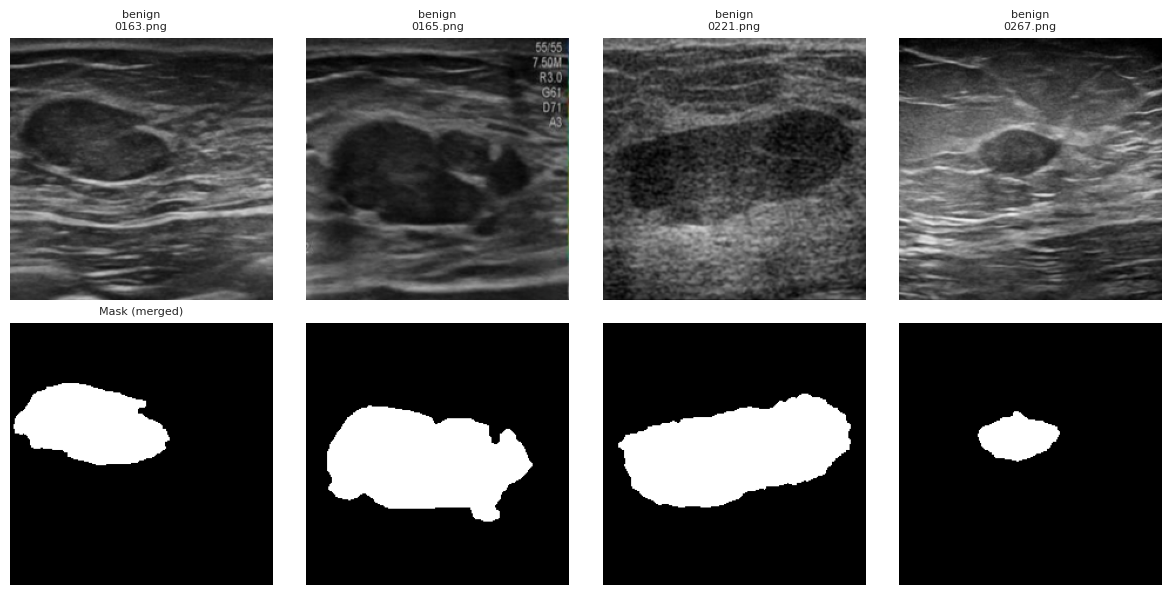

In [ ]:
# Visualise a few merged masks
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
shown = 0
for pos in range(len(eval_indices)):
    if shown >= 4: break
    if mask_index[pos] is None: continue
    idx = eval_indices[pos]
    x, _ = test_ds[idx]
    img = unnormalize(x).permute(1,2,0).numpy().clip(0,1)
    axes[0, shown].imshow(img); axes[0, shown].axis("off")
    axes[0, shown].set_title(f"{CLASS_NAMES[eval_labels[pos]]}\n{Path(test_ds.samples[idx][0]).name}",
                              fontsize=8)
    axes[1, shown].imshow(mask_index[pos], cmap="gray"); axes[1, shown].axis("off")
    axes[1, shown].set_title("Mask (merged)" if shown==0 else "", fontsize=8)
    shown += 1
plt.tight_layout(); plt.show()

## 6. The 10 XAI Methods

Each explainer is built **on-the-fly per image** instead of being cached.

In [ ]:
def get_target_layer(model):
    return model.blocks[-1].layers[-1]
target_layer = get_target_layer(model)
print(f"CAM target layer: {type(target_layer).__name__}")

CAM target layer: MaxVitLayer


In [ ]:
from pytorch_grad_cam import GradCAM, ScoreCAM, LayerCAM, AblationCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import IntegratedGradients, NoiseTunnel
from scipy.ndimage import gaussian_filter
import shap
from lime import lime_image
from skimage.segmentation import slic

METHOD_NAMES = [
    "Grad-CAM", "Score-CAM", "LayerCAM", "Ablation-CAM",
    "Integrated Gradients", "SmoothGrad",
    "RISE",
    "Grad × Input",
    "SHAP",
    "LIME",
]

CAM_CLASSES = {
    "Grad-CAM": GradCAM,
    "Score-CAM": ScoreCAM, "LayerCAM": LayerCAM, "Ablation-CAM": AblationCAM,
}

# Gradient-based methods need the input to require grad
GRAD_BASED = {"Grad-CAM", "LayerCAM",
              "Integrated Gradients", "SmoothGrad",
              "Grad × Input"}

def explain_with_cam(cam_cls, x, target):
    cam = cam_cls(model=model, target_layers=[target_layer])
    try:
        sal = cam(input_tensor=x, targets=[ClassifierOutputTarget(target)])[0]
    finally:
        del cam; free()
    return sal

def explain_ig(x, target):
    ig = IntegratedGradients(model)
    attr = ig.attribute(x, target=target, n_steps=20, internal_batch_size=IG_BATCH)
    sal = np.abs(attr.detach().cpu().numpy()[0]).max(axis=0)
    del ig, attr; free()
    return sal / (sal.max() + 1e-8)

def explain_smoothgrad(x, target):
    ig = IntegratedGradients(model)
    nt = NoiseTunnel(ig)
    attr = nt.attribute(x, target=target, nt_type="smoothgrad",
                        nt_samples=4, stdevs=0.15,
                        n_steps=15, internal_batch_size=IG_BATCH)
    sal = np.abs(attr.detach().cpu().numpy()[0]).max(axis=0)
    del ig, nt, attr; free()
    return sal / (sal.max() + 1e-8)

def explain_grad_input(x, target):
    x_req = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    out = model(x_req)
    out[0, target].backward()
    sal = (x_req.grad * x_req).detach().cpu().numpy()[0]
    sal = np.abs(sal).max(axis=0)
    del x_req, out; free()
    return sal / (sal.max() + 1e-8)


# ─── SHAP — Kernel/Partition explainer over superpixel masks ───
def explain_shap(x, target, nsamples=SHAP_NSAMPLES, n_segments=LIME_SEGMENTS):
    """
    Model-agnostic SHAP on superpixels. We segment the image, then let SHAP
    perturb whole superpixels (on/off, masked to the blurred baseline) and
    attribute the change in the target-class probability back to each
    superpixel. The per-superpixel SHAP values are painted back to a dense
    (H, W) saliency map.
    """
    img = unnormalize(x[0].cpu()).permute(1, 2, 0).numpy().clip(0, 1)
    segments = slic(img, n_segments=n_segments, compactness=10, start_label=0)
    n_seg = int(segments.max()) + 1

    # blurred baseline (what an "off" superpixel is replaced with)
    baseline = np.stack([gaussian_filter(img[..., c], sigma=8) for c in range(3)], axis=-1)

    def mask_to_image(z):
        # z: (n_samples, n_seg) binary mask over superpixels
        out = np.zeros((z.shape[0], IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
        for i in range(z.shape[0]):
            on = z[i] > 0.5
            keep = on[segments]                       # (H, W) bool
            keep3 = np.repeat(keep[..., None], 3, axis=2)
            out[i] = np.where(keep3, img, baseline)
        return out

    @torch.no_grad()
    def f(z):
        imgs = mask_to_image(z)
        t = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().to(device)
        t = torch.stack([normalize(ti) for ti in t])
        probs = F.softmax(model(t), dim=1)[:, target].cpu().numpy()
        del t
        free()
        return probs

    all_on = np.ones((1, n_seg))
    explainer = shap.KernelExplainer(f, np.zeros((1, n_seg)))
    shap_values = explainer.shap_values(all_on, nsamples=nsamples, silent=True)
    sv = np.array(shap_values).reshape(-1)            # (n_seg,)

    sal = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for s in range(n_seg):
        sal[segments == s] = sv[s]
    del explainer
    free()
    return sal


# ─── LIME — superpixel linear surrogate ───
def explain_lime(x, target, nsamples=LIME_NSAMPLES, n_segments=LIME_SEGMENTS):
    img = unnormalize(x[0].cpu()).permute(1, 2, 0).numpy().clip(0, 1)

    @torch.no_grad()
    def batch_predict(images):
        # images: list/array of (H, W, 3) float in [0, 1]
        arr = np.stack(images).astype(np.float32)
        t = torch.from_numpy(arr).permute(0, 3, 1, 2).float().to(device)
        t = torch.stack([normalize(ti) for ti in t])
        out = []
        for k in range(0, t.shape[0], RISE_BATCH):
            chunk = t[k:k + RISE_BATCH]
            out.append(F.softmax(model(chunk), dim=1).cpu().numpy())
        probs = np.concatenate(out, axis=0)
        del t
        free()
        return probs

    seg_fn = lambda im: slic(im, n_segments=n_segments, compactness=10, start_label=0)
    explainer = lime_image.LimeImageExplainer()
    exp = explainer.explain_instance(
        img, batch_predict, labels=(target,), hide_color=0,
        num_samples=nsamples, segmentation_fn=seg_fn,
    )
    segments = exp.segments
    weights = dict(exp.local_exp[target])             # {seg_id: weight}
    sal = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for seg_id, w in weights.items():
        sal[segments == seg_id] = w
    del explainer, exp
    free()
    return sal


# ─── RISE — generate masks lazily, never store them all ───
class RISE:
    def __init__(self, n_masks=RISE_N_MASKS, s=8, p1=0.5,
                 input_size=(IMG_SIZE, IMG_SIZE), batch=RISE_BATCH):
        self.n, self.s, self.p1 = n_masks, s, p1
        self.input_size, self.batch = input_size, batch

    def _make_batch(self, k):
        cell = np.ceil(np.array(self.input_size) / self.s)
        up   = (self.s + 1) * cell
        grid = (np.random.rand(k, self.s, self.s) < self.p1).astype(np.float32)
        masks = np.empty((k, *self.input_size), dtype=np.float32)
        for i in range(k):
            sx, sy = np.random.randint(0, cell[0]), np.random.randint(0, cell[1])
            m = Image.fromarray(grid[i]).resize((int(up[1]), int(up[0])),
                                                resample=Image.BILINEAR)
            masks[i] = np.array(m)[sx:sx+self.input_size[0], sy:sy+self.input_size[1]]
        return masks

    @torch.no_grad()
    def __call__(self, x, target):
        accum = torch.zeros(self.input_size, device=device)
        seen = 0
        while seen < self.n:
            k = min(self.batch, self.n - seen)
            masks = self._make_batch(k)
            mt = torch.from_numpy(masks).unsqueeze(1).to(device)
            masked = x * mt
            out = F.softmax(model(masked), dim=1)[:, target]
            accum += (mt.squeeze(1) * out.view(-1, 1, 1)).sum(0)
            seen += k
            del mt, masked, out
        sal = accum.cpu().numpy() / (self.n * self.p1)
        sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
        del accum; free()
        return sal

rise = RISE()


def run_method(name, x, target):
    # Enable gradients on parameters for gradient-based methods.
    # CAM methods backprop through the model, so the model's
    # parameters need requires_grad=True temporarily.
    needs_grad = name in GRAD_BASED
    if needs_grad:
        for p in model.parameters():
            p.requires_grad_(True)

    try:
        if name in CAM_CLASSES:
            sal = explain_with_cam(CAM_CLASSES[name], x, target)
        elif name == "Integrated Gradients":
            sal = explain_ig(x, target)
        elif name == "SmoothGrad":
            sal = explain_smoothgrad(x, target)
        elif name == "RISE":
            sal = rise(x, target)
        elif name == "Grad × Input":
            sal = explain_grad_input(x, target)
        elif name == "SHAP":
            sal = explain_shap(x, target)
        elif name == "LIME":
            sal = explain_lime(x, target)
        else:
            raise ValueError(name)
    finally:
        # Restore the memory-saving state
        if needs_grad:
            for p in model.parameters():
                p.requires_grad_(False)

    return sal

print(f"{len(METHOD_NAMES)} methods registered.")

10 methods registered.


## 7. Smoke Test

100%|██████████| 16/16 [00:03<00:00,  5.02it/s]


  0%|          | 0/1000 [00:00<?, ?it/s]

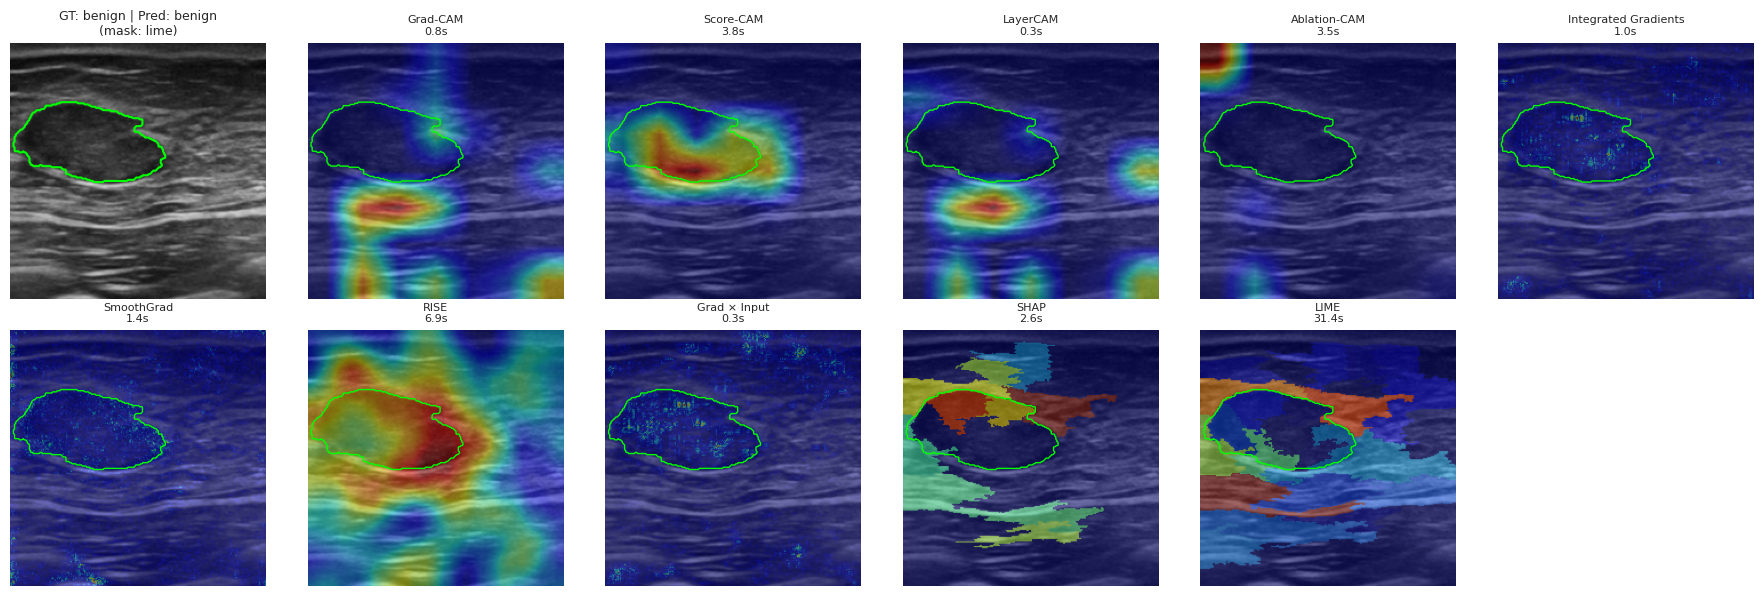

  [after smoke test] GPU alloc=0.27GB reserved=0.32GB


In [ ]:
def normalize_sal(s):
    s = np.maximum(s, 0)
    if s.max() - s.min() < 1e-8: return np.zeros_like(s)
    return (s - s.min()) / (s.max() - s.min())

test_pos = next((p for p in range(len(eval_indices)) if mask_index[p] is not None), 0)
test_idx = eval_indices[test_pos]
x0, lbl0 = test_ds[test_idx]
x0 = x0.unsqueeze(0).to(device)
with torch.no_grad():
    pred0 = model(x0).argmax(1).item()

img0 = unnormalize(x0[0].cpu()).permute(1,2,0).numpy().clip(0,1)
mask0 = mask_index[test_pos]

# Size the grid to exactly fit (1 original + N methods)
n_total = len(METHOD_NAMES) + 1
n_cols = 6
n_rows = (n_total + n_cols - 1) // n_cols   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes.flatten()

axes[0].imshow(img0)
title = f"GT: {CLASS_NAMES[lbl0]} | Pred: {CLASS_NAMES[pred0]}"
if mask0 is not None:
    axes[0].contour(mask0, levels=[0.5], colors="lime", linewidths=1.5)
    title += "\n(mask: lime)"
axes[0].set_title(title, fontsize=9); axes[0].axis("off")

for i, name in enumerate(METHOD_NAMES, start=1):
    t0 = time.time()
    try:
        sal = normalize_sal(run_method(name, x0, pred0))
        axes[i].imshow(img0); axes[i].imshow(sal, cmap="jet", alpha=0.45)
        if mask0 is not None:
            axes[i].contour(mask0, levels=[0.5], colors="lime", linewidths=1.0)
        axes[i].set_title(f"{name}\n{time.time()-t0:.1f}s", fontsize=8)
    except Exception as e:
        axes[i].text(0.5, 0.5, f"{name}\nERROR", ha="center", va="center", fontsize=8)
        print(f"  ! {name}: {e}")
    axes[i].axis("off")
    free()

# Hide any leftover empty subplots
for j in range(n_total, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "smoke_test.png"), dpi=110, bbox_inches="tight")
plt.show()
mem_report("after smoke test")

## 8. Metric Implementations

In [ ]:
@torch.no_grad()
def deletion_insertion_auc(x, sal, target, mode="deletion", n_steps=DEL_INS_STEPS):
    H, W = sal.shape
    N = H * W
    step = N // n_steps
    order = np.argsort(-sal.flatten())
    confs = []

    if mode == "deletion":
        current = x.clone()
        replace = current.mean()
    else:
        baseline = np.stack([gaussian_filter(x[0, c].cpu().numpy(), sigma=10) for c in range(3)])
        current = torch.from_numpy(baseline).unsqueeze(0).to(device).float()

    flat = current.view(1, 3, -1).clone()
    confs.append(F.softmax(model(current), dim=1)[0, target].item())

    if mode == "deletion":
        for s in range(n_steps):
            pix = order[s*step:(s+1)*step]
            flat[0, :, pix] = replace
            confs.append(F.softmax(model(flat.view(1,3,H,W)), dim=1)[0, target].item())
    else:
        orig_flat = x.view(1, 3, -1)
        for s in range(n_steps):
            pix = order[s*step:(s+1)*step]
            flat[0, :, pix] = orig_flat[0, :, pix]
            confs.append(F.softmax(model(flat.view(1,3,H,W)), dim=1)[0, target].item())

    del flat, current; free()
    return float(np.trapz(confs) / len(confs))


@torch.no_grad()
def road_score(x, sal, target, percentiles=(10, 30, 50, 70, 90)):
    confs = []
    for p in percentiles:
        thr = np.percentile(sal, 100 - p)
        m = torch.from_numpy((sal >= thr).astype(np.float32)).to(device)
        noise = torch.randn_like(x) * x.std() + x.mean()
        perturbed = x * (1 - m) + noise * m
        confs.append(F.softmax(model(perturbed), dim=1)[0, target].item())
        del m, noise, perturbed
    free()
    return float(np.mean(confs))


def threshold_topk(sal, kp=TOP_K_PERCENT):
    return (sal >= np.percentile(sal, 100 - kp)).astype(np.uint8)

def dice_coef(s, g):
    s = s.astype(np.float32); g = g.astype(np.float32)
    inter = (s*g).sum()
    return float(2 * inter / (s.sum() + g.sum() + 1e-8))

def ebpg(sal, gt):
    t = sal.sum()
    return float((sal * gt).sum() / t) if t > 1e-8 else 0.0


@torch.no_grad()
def avg_drop_increase(x, sal, target, kp=TOP_K_PERCENT):
    m = torch.from_numpy(threshold_topk(sal, kp).astype(np.float32)).to(device)
    c0 = F.softmax(model(x), dim=1)[0, target].item()
    c1 = F.softmax(model(x * m), dim=1)[0, target].item()
    drop = max(0.0, c0 - c1) / (c0 + 1e-8)
    inc  = 1.0 if c1 > c0 else 0.0
    del m; free()
    return float(drop), float(inc)

## 9. Streaming Evaluation Loop

For each image: load → predict → run all 10 methods → run all 8 metrics → save saliencies to disk → free GPU memory → next image.

Total RAM stays roughly constant at ~1-2 GB regardless of dataset size.

In [ ]:
results = {m: defaultdict(list) for m in METHOD_NAMES}
all_preds, all_labels = [], []
errors_log = []


def safe_key(m):
    return m.replace(" ", "_").replace("(", "").replace(")", "").replace("*", "star")

for pos, idx in enumerate(tqdm(eval_indices, desc="Streaming eval")):
    x, lbl = test_ds[idx]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).argmax(1).item()
    all_preds.append(pred); all_labels.append(lbl)

    gt_mask = mask_index[pos]
    img_class = CLASS_NAMES[lbl]
    saliencies_this_image = {}

    for method in METHOD_NAMES:
        try:
            sal = normalize_sal(run_method(method, x, pred))
        except torch.cuda.OutOfMemoryError:
            errors_log.append((idx, method, "OOM"))
            free()
            sal = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
            for k in ["Deletion AUC","Insertion AUC","ROAD","Dice","EBPG",
                      "Avg Drop","Avg Increase"]:
                results[method][k].append(np.nan)
            continue
        except Exception as e:
            errors_log.append((idx, method, str(e)[:80]))
            sal = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

        saliencies_this_image[method] = sal.astype(np.float32)

        # Faithfulness
        try:
            results[method]["Deletion AUC"].append(deletion_insertion_auc(x, sal, pred, "deletion"))
            results[method]["Insertion AUC"].append(deletion_insertion_auc(x, sal, pred, "insertion"))
            results[method]["ROAD"].append(road_score(x, sal, pred))
        except Exception as e:
            errors_log.append((idx, method, f"faith: {e}"))
            for k in ("Deletion AUC", "Insertion AUC", "ROAD"):
                results[method][k].append(np.nan)

        # Localisation
        if gt_mask is not None and img_class != "normal":
            sm = threshold_topk(sal)
            results[method]["Dice"].append(dice_coef(sm, gt_mask))
            results[method]["EBPG"].append(ebpg(sal, gt_mask))
        else:
            results[method]["Dice"].append(np.nan)
            results[method]["EBPG"].append(np.nan)

        # Plausibility
        try:
            d, i_ = avg_drop_increase(x, sal, pred)
            results[method]["Avg Drop"].append(d)
            results[method]["Avg Increase"].append(i_)
        except Exception as e:
            errors_log.append((idx, method, f"plaus: {e}"))
            results[method]["Avg Drop"].append(np.nan)
            results[method]["Avg Increase"].append(np.nan)

        free()

    # Save saliencies to disk, then drop from memory
    np.savez_compressed(
        os.path.join(SALIENCY_DIR, f"img_{pos:04d}.npz"),
        **{safe_key(k): v for k, v in saliencies_this_image.items()},
        label=lbl, pred=pred, image_idx=idx,
    )
    del saliencies_this_image, x
    free()

all_labels = np.array(all_labels); all_preds = np.array(all_preds)
print(f"\nDone. Classifier accuracy on subset: {(all_labels==all_preds).mean():.3f}")
print(f"Errors: {len(errors_log)}")
for e in errors_log[:10]:
    print(" ", e)
mem_report("end of eval")

## 10. Aggregate Metrics Tables (Global + per-class)

Four tables are produced, all from the same in-memory `results`:

- **Global** : all evaluated classes pooled together
- **Benign** : benign cases only
- **Malignant** : malignant cases only
- **Normal** : normal cases only

Each table reports `mean ± std` per method × metric. Localisation metrics (Dice, EBPG) are only defined for benign/malignant (normal images have no lesion masks), so they appear as `—` in the Normal table.


In [ ]:
metric_names = ["Deletion AUC", "Insertion AUC", "ROAD", "Dice", "EBPG",
                "Avg Drop", "Avg Increase"]

# all_labels[pos] gives the class of the pos-th evaluated image, and
# results[method][metric] is a per-image list in that SAME order, so we
# can slice by class with a boolean mask.
all_labels = np.asarray(all_labels)

def build_metric_table(class_name=None):
    """
    Aggregate results into a mean ± std table.
    class_name=None  -> Global (all classes pooled)
    class_name='benign'/'malignant'/'normal' -> that class only
    """
    if class_name is None:
        keep = np.ones(len(all_labels), dtype=bool)
    else:
        keep = (all_labels == CLASS_NAMES.index(class_name))

    rows = []
    for method in METHOD_NAMES:
        row = {"Method": method}
        for metric in metric_names:
            vals = np.asarray(results[method][metric], dtype=float)
            # align the per-image values with the class mask
            m = keep[:len(vals)]
            vals = vals[m]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                row[metric] = f"{vals.mean():.3f} ± {vals.std():.3f}"
                row[f"{metric}_mean"] = float(vals.mean())
                row[f"{metric}_n"] = int(len(vals))
            else:
                row[metric] = "—"
                row[f"{metric}_mean"] = np.nan
                row[f"{metric}_n"] = 0
        rows.append(row)
    return pd.DataFrame(rows)

# ── Global table (all classes) ──
df_global = build_metric_table(None)
df_global.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_global.csv"), index=False)
# keep the legacy filename too, pointing at the global table
df_global.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary.csv"), index=False)
print("Global (all classes):")
df_global[["Method"] + metric_names]


Global (all classes):


,Method,Deletion AUC,Insertion AUC,ROAD,Dice,EBPG,Avg Drop,Avg Increase
0,Grad-CAM,0.347 ± 0.109,0.564 ± 0.177,0.320 ± 0.140,0.214 ± 0.205,0.149 ± 0.151,0.494 ± 0.295,0.083 ± 0.276
1,Score-CAM,0.404 ± 0.127,0.589 ± 0.164,0.329 ± 0.127,0.292 ± 0.234,0.201 ± 0.231,0.300 ± 0.343,0.150 ± 0.357
2,LayerCAM,0.366 ± 0.108,0.577 ± 0.162,0.340 ± 0.127,0.180 ± 0.169,0.164 ± 0.166,0.474 ± 0.336,0.117 ± 0.321
3,Ablation-CAM,0.405 ± 0.135,0.557 ± 0.148,0.357 ± 0.129,0.101 ± 0.144,0.093 ± 0.139,0.479 ± 0.314,0.050 ± 0.218
4,Integrated Gradients,0.380 ± 0.107,0.538 ± 0.179,0.338 ± 0.176,0.303 ± 0.178,0.218 ± 0.164,0.515 ± 0.280,0.050 ± 0.218
5,SmoothGrad,0.348 ± 0.110,0.581 ± 0.188,0.325 ± 0.165,0.306 ± 0.183,0.204 ± 0.144,0.463 ± 0.277,0.067 ± 0.249
6,RISE,0.344 ± 0.165,0.543 ± 0.201,0.322 ± 0.182,0.236 ± 0.180,0.115 ± 0.098,0.475 ± 0.345,0.133 ± 0.340
7,Grad × Input,0.390 ± 0.108,0.522 ± 0.182,0.350 ± 0.177,0.264 ± 0.179,0.200 ± 0.175,0.519 ± 0.250,0.033 ± 0.180
8,SHAP,0.352 ± 0.097,0.632 ± 0.157,0.327 ± 0.122,0.183 ± 0.157,0.191 ± 0.188,0.378 ± 0.297,0.133 ± 0.340
9,LIME,0.323 ± 0.097,0.633 ± 0.181,0.324 ± 0.151,0.208 ± 0.169,0.157 ± 0.116,0.347 ± 0.278,0.183 ± 0.387


In [ ]:
# ════════════════════════════════════════════════════════════════
# Per-class aggregate tables: Benign / Malignant / Normal
# (built from the same `results` + `all_labels` as the global table)
# ════════════════════════════════════════════════════════════════
from IPython.display import display

per_class_tables = {}
for cls in ["benign", "malignant", "normal"]:
    df_c = build_metric_table(cls)
    df_c.to_csv(os.path.join(OUTPUT_DIR, f"metrics_summary_{cls}.csv"), index=False)
    per_class_tables[cls] = df_c
    n_imgs = int((all_labels == CLASS_NAMES.index(cls)).sum())
    print(f"\n=== {cls.upper()} only  (n = {n_imgs} images) ===")
    display(df_c[["Method"] + metric_names])

print("\nSaved: metrics_summary_global.csv, "
      "metrics_summary_benign.csv, metrics_summary_malignant.csv, "
      "metrics_summary_normal.csv")



=== BENIGN only  (n = 20 images) ===


,Method,Deletion AUC,Insertion AUC,ROAD,Dice,EBPG,Avg Drop,Avg Increase
0,Grad-CAM,0.380 ± 0.118,0.640 ± 0.188,0.306 ± 0.121,0.188 ± 0.168,0.131 ± 0.150,0.271 ± 0.230,0.150 ± 0.357
1,Score-CAM,0.396 ± 0.089,0.656 ± 0.181,0.302 ± 0.098,0.279 ± 0.189,0.173 ± 0.205,0.233 ± 0.281,0.250 ± 0.433
2,LayerCAM,0.384 ± 0.104,0.650 ± 0.156,0.316 ± 0.118,0.160 ± 0.142,0.163 ± 0.174,0.252 ± 0.262,0.150 ± 0.357
3,Ablation-CAM,0.449 ± 0.121,0.597 ± 0.147,0.379 ± 0.132,0.065 ± 0.085,0.071 ± 0.122,0.323 ± 0.259,0.100 ± 0.300
4,Integrated Gradients,0.397 ± 0.093,0.595 ± 0.201,0.338 ± 0.099,0.283 ± 0.162,0.218 ± 0.171,0.412 ± 0.263,0.100 ± 0.300
5,SmoothGrad,0.376 ± 0.093,0.640 ± 0.188,0.326 ± 0.102,0.271 ± 0.159,0.193 ± 0.138,0.353 ± 0.245,0.050 ± 0.218
6,RISE,0.443 ± 0.144,0.652 ± 0.206,0.320 ± 0.149,0.266 ± 0.197,0.120 ± 0.110,0.241 ± 0.302,0.250 ± 0.433
7,Grad × Input,0.417 ± 0.110,0.556 ± 0.211,0.378 ± 0.133,0.242 ± 0.161,0.190 ± 0.178,0.451 ± 0.243,0.100 ± 0.300
8,SHAP,0.345 ± 0.083,0.695 ± 0.146,0.322 ± 0.099,0.155 ± 0.142,0.167 ± 0.170,0.227 ± 0.274,0.300 ± 0.458
9,LIME,0.342 ± 0.108,0.696 ± 0.197,0.335 ± 0.125,0.203 ± 0.168,0.156 ± 0.114,0.173 ± 0.265,0.500 ± 0.500



=== MALIGNANT only  (n = 20 images) ===


,Method,Deletion AUC,Insertion AUC,ROAD,Dice,EBPG,Avg Drop,Avg Increase
0,Grad-CAM,0.349 ± 0.123,0.578 ± 0.150,0.446 ± 0.105,0.241 ± 0.234,0.166 ± 0.149,0.505 ± 0.317,0.100 ± 0.300
1,Score-CAM,0.376 ± 0.133,0.612 ± 0.143,0.459 ± 0.086,0.305 ± 0.270,0.228 ± 0.251,0.408 ± 0.349,0.150 ± 0.357
2,LayerCAM,0.370 ± 0.125,0.598 ± 0.148,0.460 ± 0.074,0.199 ± 0.191,0.165 ± 0.157,0.468 ± 0.364,0.200 ± 0.400
3,Ablation-CAM,0.390 ± 0.159,0.595 ± 0.137,0.455 ± 0.073,0.137 ± 0.178,0.115 ± 0.151,0.531 ± 0.312,0.050 ± 0.218
4,Integrated Gradients,0.433 ± 0.119,0.588 ± 0.138,0.524 ± 0.111,0.323 ± 0.191,0.218 ± 0.157,0.329 ± 0.185,0.050 ± 0.218
5,SmoothGrad,0.424 ± 0.094,0.622 ± 0.146,0.489 ± 0.123,0.341 ± 0.197,0.215 ± 0.148,0.283 ± 0.180,0.150 ± 0.357
6,RISE,0.375 ± 0.173,0.606 ± 0.138,0.487 ± 0.140,0.205 ± 0.155,0.110 ± 0.083,0.432 ± 0.347,0.150 ± 0.357
7,Grad × Input,0.435 ± 0.110,0.595 ± 0.116,0.512 ± 0.104,0.286 ± 0.192,0.211 ± 0.171,0.335 ± 0.129,0.000 ± 0.000
8,SHAP,0.372 ± 0.105,0.639 ± 0.160,0.449 ± 0.066,0.211 ± 0.166,0.216 ± 0.202,0.274 ± 0.275,0.100 ± 0.300
9,LIME,0.338 ± 0.108,0.661 ± 0.164,0.455 ± 0.112,0.213 ± 0.169,0.157 ± 0.119,0.310 ± 0.207,0.050 ± 0.218



=== NORMAL only  (n = 20 images) ===


,Method,Deletion AUC,Insertion AUC,ROAD,Dice,EBPG,Avg Drop,Avg Increase
0,Grad-CAM,0.311 ± 0.063,0.474 ± 0.150,0.210 ± 0.070,—,—,0.705 ± 0.114,0.000 ± 0.000
1,Score-CAM,0.441 ± 0.144,0.500 ± 0.120,0.227 ± 0.053,—,—,0.258 ± 0.367,0.050 ± 0.218
2,LayerCAM,0.343 ± 0.089,0.484 ± 0.134,0.243 ± 0.069,—,—,0.702 ± 0.193,0.000 ± 0.000
3,Ablation-CAM,0.376 ± 0.108,0.478 ± 0.127,0.236 ± 0.046,—,—,0.582 ± 0.306,0.000 ± 0.000
4,Integrated Gradients,0.309 ± 0.056,0.430 ± 0.138,0.153 ± 0.039,—,—,0.803 ± 0.060,0.000 ± 0.000
5,SmoothGrad,0.245 ± 0.042,0.481 ± 0.183,0.160 ± 0.047,—,—,0.752 ± 0.098,0.000 ± 0.000
6,RISE,0.214 ± 0.062,0.370 ± 0.119,0.159 ± 0.063,—,—,0.752 ± 0.111,0.000 ± 0.000
7,Grad × Input,0.319 ± 0.053,0.414 ± 0.151,0.159 ± 0.044,—,—,0.771 ± 0.098,0.000 ± 0.000
8,SHAP,0.339 ± 0.099,0.563 ± 0.136,0.210 ± 0.043,—,—,0.631 ± 0.129,0.000 ± 0.000
9,LIME,0.289 ± 0.055,0.543 ± 0.138,0.182 ± 0.052,—,—,0.557 ± 0.209,0.000 ± 0.000



Saved: metrics_summary_global.csv, metrics_summary_benign.csv, metrics_summary_malignant.csv, metrics_summary_normal.csv


## 11. Friedman Test + Critical Difference Diagrams

In [ ]:
from scipy.stats import friedmanchisquare

def friedman_for(metric, methods, direction):
    mat = np.array([results[m][metric] for m in methods])
    valid = ~np.isnan(mat).any(axis=0)
    mat = mat[:, valid]
    if mat.shape[1] < 5:
        return None, None, None, mat.shape[1]
    work = -mat if direction == "higher" else mat
    stat, p = friedmanchisquare(*work)
    ranks = np.array([np.argsort(np.argsort(col)) for col in work.T]).mean(axis=0) + 1
    return float(stat), float(p), dict(zip(methods, ranks)), mat.shape[1]

directions = {
    "Deletion AUC":"lower","Insertion AUC":"higher","ROAD":"lower",
    "Dice":"higher","EBPG":"higher",
    "Avg Drop":"lower","Avg Increase":"higher",
}

ranks_table = {}
print(f"{'Metric':<18} {'χ²':>8} {'p':>8} {'N':>4}   Top-3 (rank)")
print("─"*80)
for metric, dr in directions.items():
    res = friedman_for(metric, METHOD_NAMES, dr)
    if res[0] is None:
        print(f"{metric:<18} {'—':>8} {'—':>8} {res[3]:>4}   insufficient data")
        continue
    stat, p, ranks, n = res
    ranks_table[metric] = ranks
    top3 = sorted(ranks.items(), key=lambda kv: kv[1])[:3]
    top3s = ", ".join(f"{m}({r:.2f})" for m, r in top3)
    print(f"{metric:<18} {stat:>8.2f} {p:>8.4f} {n:>4}   {top3s}")

Metric                   χ²        p    N   Top-3 (rank)
────────────────────────────────────────────────────────────────────────────────
Deletion AUC          59.60   0.0000   60   LIME(3.95), RISE(4.63), SmoothGrad(4.72)
Insertion AUC        106.44   0.0000   60   LIME(3.13), SHAP(3.33), Score-CAM(5.03)
ROAD                  21.70   0.0099   60   RISE(4.67), Grad-CAM(4.88), SmoothGrad(5.02)
Dice                  75.59   0.0000   40   Score-CAM(3.70), Integrated Gradients(4.00), SmoothGrad(4.10)
EBPG                  74.47   0.0000   40   Integrated Gradients(3.83), SmoothGrad(4.10), Grad × Input(5.00)
Avg Drop              63.04   0.0000   60   LIME(3.98), Score-CAM(4.23), SHAP(4.48)
Avg Increase          21.09   0.0123   60   Grad-CAM(1.67), Score-CAM(2.52), LayerCAM(3.18)


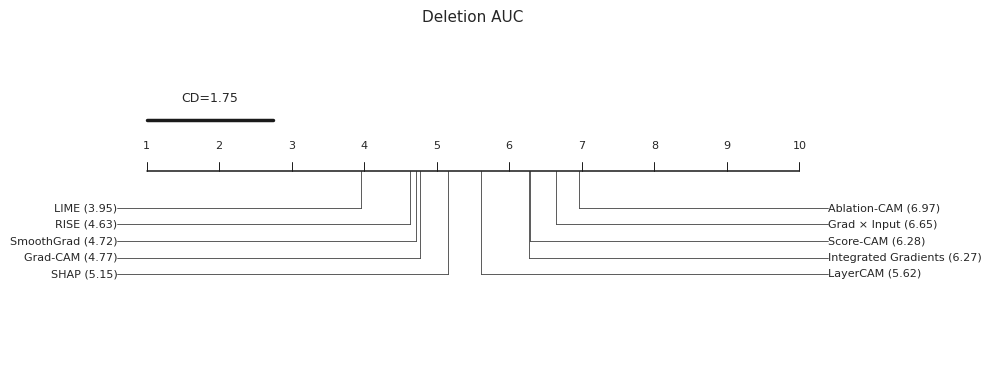

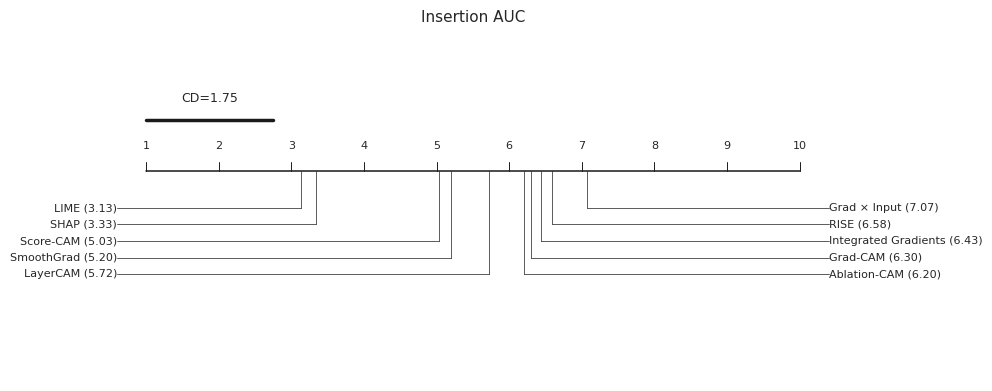

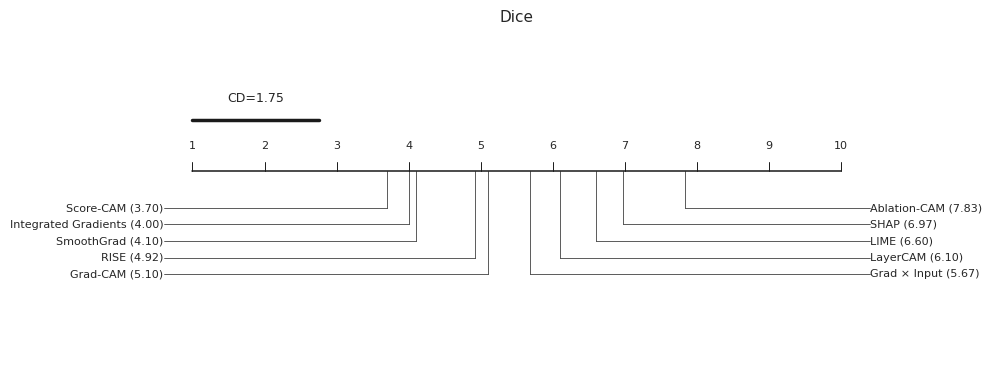

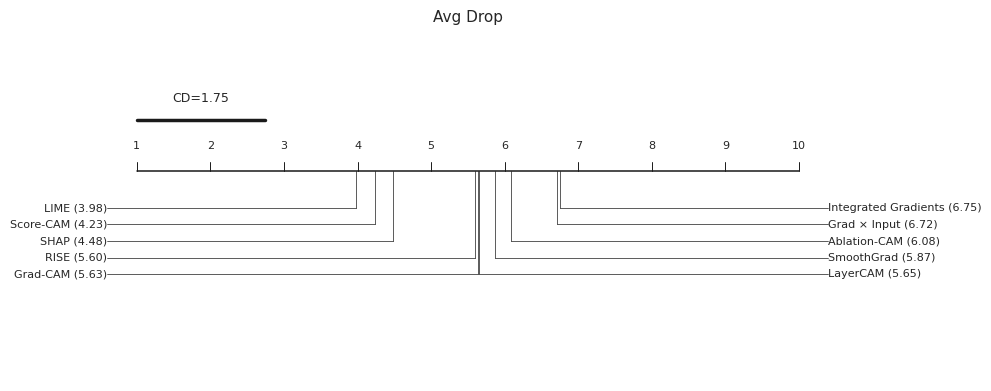

In [ ]:
from scipy.stats import studentized_range

def cd_diagram(ranks_dict, n_datasets, alpha=0.05, title=""):
    methods_ = list(ranks_dict.keys())
    ranks = np.array(list(ranks_dict.values()))
    k = len(methods_)
    q = studentized_range.ppf(1-alpha, k, np.inf) / np.sqrt(2)
    cd = q * np.sqrt(k*(k+1)/(6*n_datasets))

    order = np.argsort(ranks)
    sm = [methods_[i] for i in order]
    sr = ranks[order]

    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.4*k)))
    ax.set_xlim(0.5, k+0.5); ax.set_ylim(-1.2*((k+1)//2)*0.18-1.2, 1.5); ax.axis("off")
    for r in range(1, k+1):
        ax.plot([r,r],[0,0.1],"k-",lw=0.7)
        ax.text(r,0.22,str(r),ha="center",va="bottom",fontsize=8)
    ax.plot([1,k],[0,0],"k-",lw=1.1)
    for i,(m,r) in enumerate(zip(sm,sr)):
        side = -1 if i < k/2 else 1
        y = -0.4 - (i if side<0 else k-1-i)*0.18
        x_text = 0.6 if side<0 else k+0.4
        ax.plot([r,r],[0,y],"k-",lw=0.5)
        ax.plot([r,x_text],[y,y],"k-",lw=0.5)
        ha = "right" if side<0 else "left"
        ax.text(x_text, y, f"{m} ({r:.2f})", ha=ha, va="center", fontsize=8)
    ax.plot([1, 1+cd], [0.55, 0.55], "k-", lw=2.5)
    ax.text(1+cd/2, 0.75, f"CD={cd:.2f}", ha="center", fontsize=9)
    ax.set_title(title, fontsize=11, pad=8)
    plt.tight_layout()
    return fig

primary = ["Deletion AUC", "Insertion AUC", "Dice", "Avg Drop"]
for metric in primary:
    if metric not in ranks_table:
        print(f"Skipping {metric} — insufficient data.")
        continue
    fig = cd_diagram(ranks_table[metric], len(eval_indices), title=metric)
    fig.savefig(os.path.join(OUTPUT_DIR, f"cd_{metric.replace(' ','_')}.png"),
                dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 12. Kendall τ Disagreement Heatmap

Loads saliencies back from disk one image at a time.

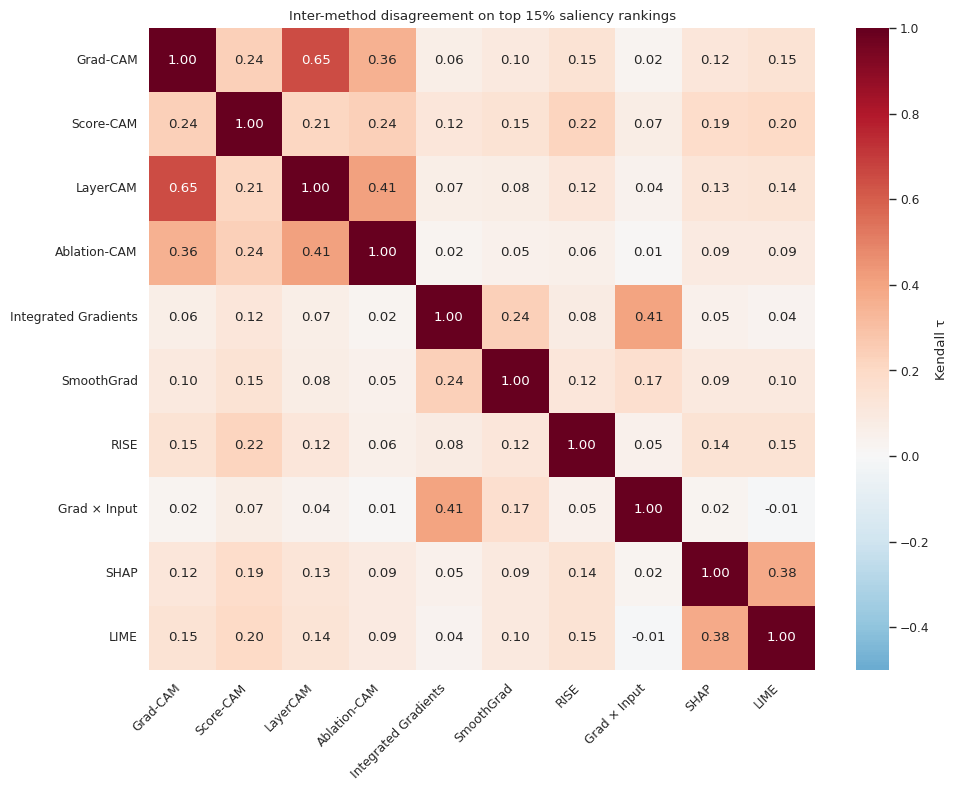

In [ ]:
from scipy.stats import kendalltau

M = len(METHOD_NAMES)
tau_mat = np.eye(M)
n_imgs = len(eval_indices)

for i, m1 in enumerate(METHOD_NAMES):
    for j, m2 in enumerate(METHOD_NAMES):
        if j <= i: continue
        taus = []
        for pos in range(n_imgs):
            path = os.path.join(SALIENCY_DIR, f"img_{pos:04d}.npz")
            d = np.load(path)
            try:
                s1, s2 = d[safe_key(m1)], d[safe_key(m2)]
                thr1 = np.percentile(s1, 100-TOP_K_PERCENT)
                thr2 = np.percentile(s2, 100-TOP_K_PERCENT)
                f1 = s1.flatten() * (s1.flatten() >= thr1)
                f2 = s2.flatten() * (s2.flatten() >= thr2)
                if f1.std() < 1e-8 or f2.std() < 1e-8:
                    continue
                t, _ = kendalltau(f1, f2)
                if not np.isnan(t): taus.append(t)
            finally:
                d.close()
        tau_mat[i,j] = tau_mat[j,i] = np.mean(taus) if taus else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(tau_mat, annot=True, fmt=".2f",
            xticklabels=METHOD_NAMES, yticklabels=METHOD_NAMES,
            cmap="RdBu_r", center=0, vmin=-0.5, vmax=1, ax=ax,
            cbar_kws={"label":"Kendall τ"})
plt.title("Inter-method disagreement on top 15% saliency rankings")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "disagreement_tau.png"), dpi=120, bbox_inches="tight")
plt.show()

## 13. Per-class Boxplots

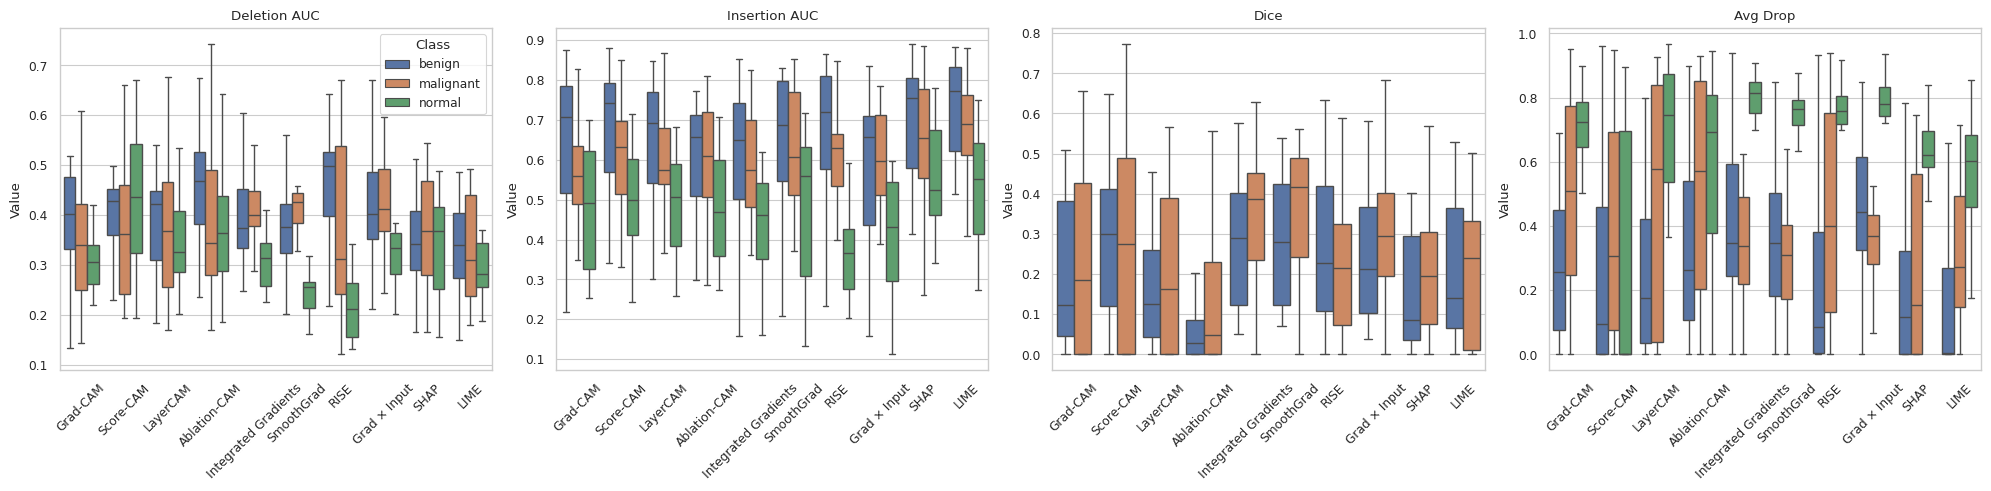

In [ ]:
records = []
for method in METHOD_NAMES:
    for metric in metric_names:
        for v, c in zip(results[method][metric], all_labels):
            if not np.isnan(v):
                records.append({"Method": method, "Metric": metric,
                                "Class": CLASS_NAMES[c], "Value": v})
long_df = pd.DataFrame(records)
long_df.to_csv(os.path.join(OUTPUT_DIR, "metrics_long.csv"), index=False)

g_metrics = ["Deletion AUC", "Insertion AUC", "Dice", "Avg Drop"]
fig, axes = plt.subplots(1, len(g_metrics), figsize=(5*len(g_metrics), 5))
for ax, metric in zip(axes, g_metrics):
    sub = long_df[long_df["Metric"] == metric]
    if sub.empty:
        ax.axis("off"); continue
    sns.boxplot(data=sub, x="Method", y="Value", hue="Class", ax=ax, showfliers=False)
    ax.set_title(metric); ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("")
    if ax is not axes[0] and ax.get_legend(): ax.get_legend().remove()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class.png"), dpi=120, bbox_inches="tight")
plt.show()

## 14. Qualitative Comparison Figure

Loads the saved saliencies for one benign + one malignant case (both correctly predicted, both with masks).

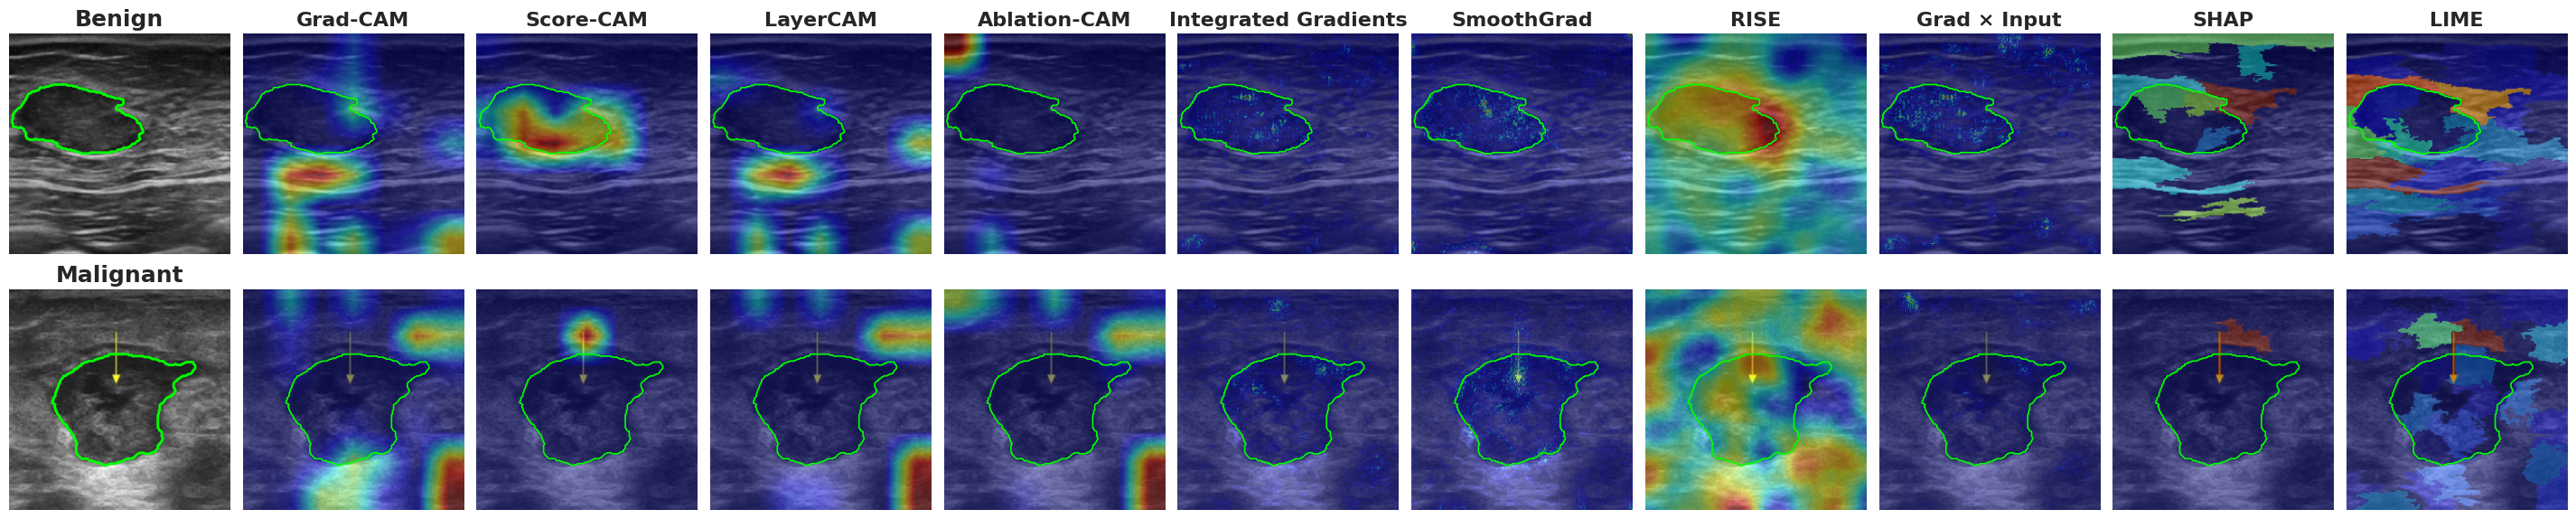

In [ ]:
def find_case(cls_name):
    target = CLASS_NAMES.index(cls_name)
    for pos in range(len(eval_indices)):
        if (all_labels[pos] == target and all_preds[pos] == target
                and mask_index[pos] is not None):
            return pos
    return None

cases = []
for cls in ("benign", "malignant"):
    p = find_case(cls)
    if p is not None: cases.append((cls.capitalize(), p))

if not cases:
    print("No correctly-predicted cases with masks found.")
else:
    n_cols = len(METHOD_NAMES) + 1
    fig, axes = plt.subplots(
        len(cases), n_cols,
        figsize=(2.6*n_cols, 3.0*len(cases)),
        squeeze=False,
    )
    for row, (cn, p) in enumerate(cases):
        d = np.load(os.path.join(SALIENCY_DIR, f"img_{p:04d}.npz"))
        x, _ = test_ds[eval_indices[p]]
        img = unnormalize(x).permute(1, 2, 0).numpy().clip(0, 1)
        mask = mask_index[p]

        axes[row, 0].imshow(img); axes[row, 0].axis("off")
        if mask is not None:
            axes[row, 0].contour(mask, levels=[0.5], colors="lime", linewidths=2.0)
        axes[row, 0].set_title(cn, fontsize=18, fontweight="bold")

        for col, method in enumerate(METHOD_NAMES, start=1):
            sal = d[safe_key(method)]
            axes[row, col].imshow(img)
            axes[row, col].imshow(sal, cmap="jet", alpha=0.45)
            if mask is not None:
                axes[row, col].contour(mask, levels=[0.5], colors="lime", linewidths=1.2)
            if row == 0:
                axes[row, col].set_title(method, fontsize=16, fontweight="bold")
            axes[row, col].axis("off")
        d.close()

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, "qualitative_final.png"),
        dpi=200, bbox_inches="tight",
    )
    plt.show()

## 15. Final Save

In [ ]:
with open(os.path.join(OUTPUT_DIR, "raw_results.json"), "w") as f:
    json.dump({m: {k: list(map(float, v)) for k, v in mv.items()}
               for m, mv in results.items()}, f, indent=2)

np.save(os.path.join(OUTPUT_DIR, "kendall_tau.npy"), tau_mat)
np.save(os.path.join(OUTPUT_DIR, "labels.npy"),     all_labels)
np.save(os.path.join(OUTPUT_DIR, "preds.npy"),      all_preds)

print(f"\nAll outputs in {OUTPUT_DIR}/")
for f in sorted(os.listdir(OUTPUT_DIR)):
    full = os.path.join(OUTPUT_DIR, f)
    if os.path.isdir(full):
        n = len(os.listdir(full))
        print(f"  [dir] {f}/  ({n} files)")
    else:
        print(f"  [file] {f}")


All outputs in xai_outputs/
  [file] cd_Avg_Drop.png
  [file] cd_Dice.png
  [file] disagreement_tau.png
  [file] kendall_tau.npy
  [file] labels.npy
  [file] metrics_long.csv
  [file] metrics_summary.csv
  [file] metrics_summary_benign.csv
  [file] metrics_summary_global.csv
  [file] metrics_summary_malignant.csv
  [file] metrics_summary_normal.csv
  [file] per_class.png
  [file] preds.npy
  [file] qualitative.png
  [file] raw_results.json
  [dir] saliencies/  (60 files)
  [file] smoke_test.png


## 16. Computational Cost & Timing (single image)

It runs each of the ten XAI methods **once on a single image** and reports:

- **Time / image** (wall-clock, seconds)
- **Peak GPU memory / image** (MB, the extra GPU memory the method allocates)
- **Forward passes / image** (number of `model(...)` calls, a hardware-independent
  cost proxy; e.g. RISE and LIME need many, gradient methods very few)

Set `N_REPEATS > 1` for steadier timings (slower); `WARMUP = True` runs one
untimed pass first to remove cold-start bias.


Profiling image idx=14  GT=benign  Pred=benign  (repeats=1, warmup=False)

  Grad-CAM                 0.890s      469.2 MB       1 fwd


100%|██████████| 32/32 [00:03<00:00,  9.14it/s]


  Score-CAM                3.866s      937.8 MB      33 fwd
  LayerCAM                 0.306s      336.0 MB       1 fwd


100%|██████████| 16/16 [00:03<00:00,  5.12it/s]


  Ablation-CAM             3.437s     1075.9 MB      18 fwd
  Integrated Gradients     0.989s      624.6 MB      10 fwd
  SmoothGrad               1.460s     1258.0 MB      15 fwd
  RISE                     6.803s      540.7 MB      63 fwd
  Grad × Input             0.308s      247.9 MB       1 fwd
  SHAP                     2.666s     6703.5 MB       3 fwd


  0%|          | 0/1000 [00:00<?, ?it/s]

  LIME                    32.183s      335.2 MB     100 fwd

Saved: xai_outputs/xai_cost_per_image.csv


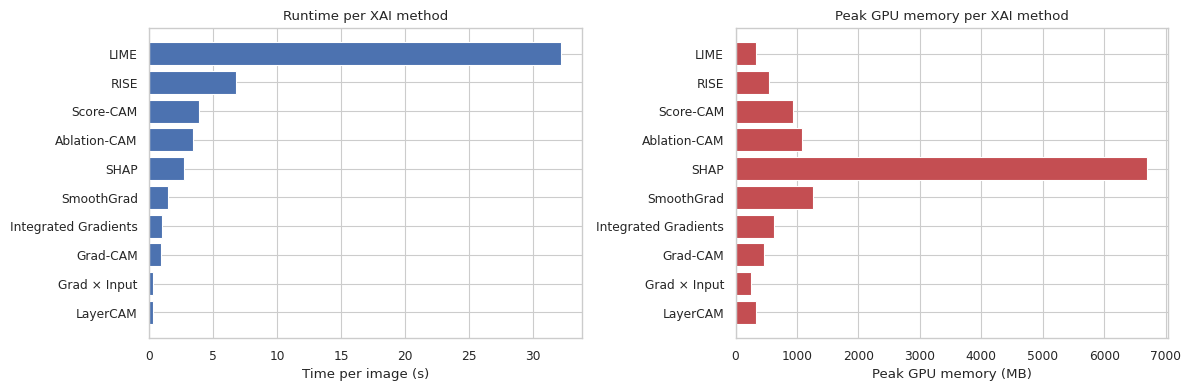

,Method,Time/img (s),Peak GPU mem (MB),Forward passes,Note
0,LIME,32.183214,335.175680,100,
1,RISE,6.803112,540.741632,63,
2,Score-CAM,3.865543,937.794048,33,
3,Ablation-CAM,3.436984,1075.874816,18,
4,SHAP,2.666210,6703.513600,3,
5,SmoothGrad,1.459684,1258.000896,15,
6,Integrated Gradients,0.989229,624.637440,10,
7,Grad-CAM,0.889660,469.171200,1,
8,Grad × Input,0.308073,247.903232,1,
9,LayerCAM,0.306194,335.980032,1,


In [ ]:
# ════════════════════════════════════════════════════════════════
#  COMPUTATIONAL COST & TIMING  —  one image, all 10 methods
#  Self-contained: needs only `model`, `run_method`, `METHOD_NAMES`,
#  `test_ds`, `eval_indices`, `device`, `free`, `OUTPUT_DIR`.
# ════════════════════════════════════════════════════════════════
import time as _time
import numpy as _np
import pandas as _pd
import torch as _torch

# ─── knobs ───────────────────────────────────────────────────────
N_REPEATS = 1        # timed runs per method (mean is reported); raise for stability
WARMUP    = False    # one untimed pass first to remove cold-start bias (doubles cost)

# ─── pick ONE image (prefer a benign/malignant case that has a mask) ───
try:
    _pos = next(p for p in range(len(eval_indices)) if mask_index[p] is not None)
except (NameError, StopIteration):
    _pos = 0
_idx = eval_indices[_pos]
_x, _lbl = test_ds[_idx]
_x = _x.unsqueeze(0).to(device)
with _torch.no_grad():
    _pred = model(_x).argmax(1).item()
print(f"Profiling image idx={_idx}  GT={CLASS_NAMES[_lbl]}  Pred={CLASS_NAMES[_pred]}  "
      f"(repeats={N_REPEATS}, warmup={WARMUP})\n")

# ─── count model forward passes via a forward hook ───────────────
_fwd = {"n": 0}
def _count_hook(_m, _inp, _out):
    _fwd["n"] += 1
_handle = model.register_forward_hook(_count_hook)

_is_cuda = (device.type == "cuda")
_rows = []

for _name in METHOD_NAMES:
    free()
    # optional warm-up (not timed, not counted)
    if WARMUP:
        try:
            run_method(_name, _x, _pred)
        except Exception:
            pass
        free()

    _times, _peaks, _fwds, _err = [], [], [], None
    for _r in range(N_REPEATS):
        free()
        if _is_cuda:
            _torch.cuda.reset_peak_memory_stats()
            _base = _torch.cuda.memory_allocated()
            _torch.cuda.synchronize()
        _fwd["n"] = 0
        _t0 = _time.perf_counter()
        try:
            _ = run_method(_name, _x, _pred)
        except Exception as _e:
            _err = str(_e)[:60]
            break
        if _is_cuda:
            _torch.cuda.synchronize()
        _t1 = _time.perf_counter()

        _times.append(_t1 - _t0)
        _fwds.append(_fwd["n"])
        if _is_cuda:
            _peaks.append((_torch.cuda.max_memory_allocated() - _base) / 1e6)  # MB

    if _err is not None:
        _rows.append({"Method": _name, "Time/img (s)": _np.nan,
                      "Peak GPU mem (MB)": _np.nan, "Forward passes": _np.nan,
                      "Note": f"ERROR: {_err}"})
        print(f"  ! {_name}: {_err}")
    else:
        _rows.append({
            "Method": _name,
            "Time/img (s)": float(_np.mean(_times)),
            "Peak GPU mem (MB)": float(_np.mean(_peaks)) if _peaks else _np.nan,
            "Forward passes": int(_np.median(_fwds)),
            "Note": "",
        })
        print(f"  {_name:<22} {_np.mean(_times):7.3f}s   "
              f"{(_np.mean(_peaks) if _peaks else float('nan')):8.1f} MB   "
              f"{int(_np.median(_fwds)):>5} fwd")
    free()

_handle.remove()

# ─── results table (sorted slowest → fastest) ───────────────────
cost_df = _pd.DataFrame(_rows).sort_values("Time/img (s)", ascending=False,
                                           na_position="last").reset_index(drop=True)
_csv = os.path.join(OUTPUT_DIR, "xai_cost_per_image.csv")
cost_df.to_csv(_csv, index=False)
print(f"\nSaved: {_csv}")

# ─── compact bar chart (time + memory) ──────────────────────────
import matplotlib.pyplot as _plt
_plot = cost_df.dropna(subset=["Time/img (s)"]).iloc[::-1]   # fastest at top
fig, ax = _plt.subplots(1, 2, figsize=(12, 4))
ax[0].barh(_plot["Method"], _plot["Time/img (s)"], color="#4C72B0")
ax[0].set_xlabel("Time per image (s)"); ax[0].set_title("Runtime per XAI method")
if _is_cuda:
    ax[1].barh(_plot["Method"], _plot["Peak GPU mem (MB)"], color="#C44E52")
    ax[1].set_xlabel("Peak GPU memory (MB)")
    ax[1].set_title("Peak GPU memory per XAI method")
else:
    ax[1].barh(_plot["Method"], _plot["Forward passes"], color="#55A868")
    ax[1].set_xlabel("Forward passes"); ax[1].set_title("Model forward passes (CPU run)")
_plt.tight_layout()
_plt.savefig(os.path.join(OUTPUT_DIR, "xai_cost_per_image.png"), dpi=120, bbox_inches="tight")
_plt.show()

cost_df
